In [ ]:
PROJECT_NAME = "OpenField-Sahand-2026-05-09"
videofile_path = [f"/content/drive/My Drive/{project_folder_name}/videos/"]   #Edit this with your own video_path
PCUTOFF = 0.4
SNAPSHOT_PATH = "..." #Edit if you have snapshot

# **Project Setup**

```markdown
In this section, we clone the DeepLabCut repository from GitHub and install it. This provides the necessary environment and libraries to run the pose estimation pipeline.
```

In [ ]:
# We clone the repository directly to ensure we have the latest stable features and utilities provided by the DLC team.
!git clone -l -s https://github.com/DeepLabCut/DeepLabCut.git cloned-DLC-repo
%cd cloned-DLC-repo
!ls

Cloning into 'cloned-DLC-repo'...
remote: Enumerating objects: 31310, done.
remote: Counting objects: 100% (1735/1735), done.
remote: Compressing objects: 100% (822/822), done.
remote: Total 31310 (delta 1165), reused 984 (delta 899), pack-reused 29575 (from 3)
Receiving objects: 100% (31310/31310), 205.55 MiB | 33.70 MiB/s, done.
Resolving deltas: 100% (21774/21774), done.
/content/cloned-DLC-repo
AUTHORS		    deeplabcut	LICENSE		setup.py	   uv.lock
CODE_OF_CONDUCT.md  dlc.py	NOTICE.yml	tests
conda-environments  docker	pyproject.toml	testscript_cli.py
_config.yml	    docs	README.md	_toc.yml
CONTRIBUTING.md     examples	reinstall.sh	tools


In [ ]:
%cd /content/cloned-DLC-repo/
%pip install "."

/content/cloned-DLC-repo
Processing /content/cloned-DLC-repo
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 14.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tifffile to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 47.6 MB/

In [ ]:
import deeplabcut

# **Dataset Preparation**

```markdown
Here, we mount Google Drive to access your project files. We define paths for the config file and videos, and then create the training dataset which reformats your labels for the neural network.
```

In [ ]:
# Mounting Google Drive is essential to persist your project data, videos, and trained model weights across different Colab sessions.
from google.colab import drive
drive.mount("/content/drive")

project_folder_name = "OpenField-Sahand-2026-05-09"
videofile_path = [f"/content/drive/My Drive/{project_folder_name}/videos/"]
video_type = "mp4"

# Defining the destination folder ensures organized storage for the generated tracking data and videos.
destfolder = f"/content/drive/My Drive/{project_folder_name}/labeled-videos"

# The config file is the 'brain' of the project, containing all metadata about body parts and training parameters.
path_config_file = f"/content/drive/My Drive/{project_folder_name}/config.yaml"
print(path_config_file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['/content/drive/My Drive/OpenField-Sahand-2026-05-09/videos/']
/content/drive/My Drive/OpenField-Sahand-2026-05-09/config.yaml


In [ ]:
# Creating the training dataset is necessary to convert raw annotations into a format compatible with PyTorch/TensorFlow.
# We use 'resnet_50' as a balanced choice between processing speed and tracking accuracy.
deeplabcut.create_training_dataset(path_config_file, augmenter_type="albumentations", net_type="resnet_50", detector_type="fasterrcnn_resnet50_fpn_v2")

[(0.95,
  1,
  (array([26, 35, 59, 28, 11,  2, 34, 58, 40, 22,  4, 10, 30, 41, 33, 43, 49,
           7, 14, 32, 50, 29, 42, 54, 18, 56, 27, 15,  5, 31, 16, 51, 20, 52,
           8, 13, 25, 37, 17, 45, 48, 57, 38,  1, 12, 46, 24,  6, 23, 36, 21,
          19,  9, 39, 55,  3,  0]),
   array([53, 47, 44])))]

# **Training**

```markdown
This section handles the neural network training. It uses the training dataset created earlier and updates the model weights to recognize the body parts labeled in your frames.
```

In [ ]:
# We point to a specific snapshot to resume training or start from a pre-trained state, saving time.
snapshot = "/content/drive/MyDrive/OpenField-Sahand-2026-05-09/dlc-models-pytorch/iteration-0/OpenFieldMay9-trainset95shuffle1/train/snapshot-100.pt"

# Training for 100 epochs allows the network to iteratively minimize the loss function and learn the visual features of your animal.
deeplabcut.train_network(
    path_config_file,
    shuffle=1,
    snapshot_path=snapshot,
    displayiters=1,
    epochs=100)

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: /content/drive/My Drive/OpenField-Sahand-2026-05-09
  pose_config_path: /content/drive/My Drive/OpenField-Sahand-2026-05-09/dlc-models-pytorch/iteration-0/OpenFieldMay9-trainset95shuffle1/train/pytorch_config.yaml
  bodyparts: ['Snout', 'Left_ear', 'Right_ear', 'Spine_1', 'Spine_2', 'R_leg', 'L_leg', 'Neck', 'Tailbase', 'tail_1', 'tail_2', 'tail_3']
  unique_bodyparts: []
  individuals: ['animal']
  with_ide

# **Model Evaluation**

```markdown
After training, we evaluate the model's performance on unseen test data. This calculates the Error (RMSE) and accuracy metrics (mAP) to ensure the model generalizes well.
```

In [ ]:
# Evaluation is critical to check for 'overfitting'; we want to see low RMSE on both training and test sets to ensure the model works on new videos.
deeplabcut.evaluate_network(path_config_file, Shuffles=[1], plotting=True)

Evaluation scorer: DLC_Resnet50_OpenFieldMay9shuffle1_snapshot_best-110


100%|██████████| 3/3 [00:00<00:00, 47.41it/s]


Evaluation results file: DLC_Resnet50_OpenFieldMay9shuffle1_snapshot_best-110-results.csv
Evaluation results for DLC_Resnet50_OpenFieldMay9shuffle1_snapshot_best-110-results.csv (pcutoff: 0.6):
train rmse              1.95
train rmse_pcutoff      1.65
train mAP              99.80
train mAR              99.82
test rmse               2.50
test rmse_pcutoff       2.50
test mAP              100.00
test mAR              100.00
Name: (0.95, 1, 110, -1, 0.6), dtype: float64


# **Video Inference**

```markdown
Once the model is trained and validated, we use it to analyze new videos. This step outputs the coordinates (x, y) and likelihood for each body part into a CSV or H5 file.
```

In [ ]:
# This is the 'inference' phase where the model actually predicts coordinates on new, unseen data.
# Saving as CSV allows for easy post-hoc analysis in software like Excel, R, or Python.
video = ["/content/drive/My Drive/OpenField-Sahand-2026-05-09/videos/m3v1mp4.mp4"]
deeplabcut.analyze_videos(path_config_file, video , save_as_csv=True, destfolder=destfolder)

Creating the output folder /content/drive/My Drive/OpenField-Sahand-2026-05-09/labeled-videos
Analyzing videos with /content/drive/My Drive/OpenField-Sahand-2026-05-09/dlc-models-pytorch/iteration-0/OpenFieldMay9-trainset95shuffle1/train/snapshot-best-110.pt
Using scorer: DLC_Resnet50_OpenFieldMay9shuffle1_snapshot_best-110
Starting to analyze /content/drive/My Drive/OpenField-Sahand-2026-05-09/videos/m3v1mp4.mp4
Video metadata: 
  Overall # of frames:    2330
  Duration of video [s]:  77.67
  fps:                    30.0
  resolution:             w=640, h=480

Running pose prediction with batch size 8


100%|██████████| 2330/2330 [01:04<00:00, 36.19it/s]


Saving results in /content/drive/My Drive/OpenField-Sahand-2026-05-09/labeled-videos/m3v1mp4DLC_Resnet50_OpenFieldMay9shuffle1_snapshot_best-110.h5 and /content/drive/My Drive/OpenField-Sahand-2026-05-09/labeled-videos/m3v1mp4DLC_Resnet50_OpenFieldMay9shuffle1_snapshot_best-110_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_OpenFieldMay9shuffle1_snapshot_best-110'

***Behavioral Visualization***

```markdown
Finally, we generate plots of the trajectories and create a labeled version of the video to visually verify the tracking quality.
```

Loading  /content/drive/My Drive/OpenField-Sahand-2026-05-09/videos/m3v1mp4.mp4 and data.
Plots created! Please check the directory "plot-poses" within the video directory


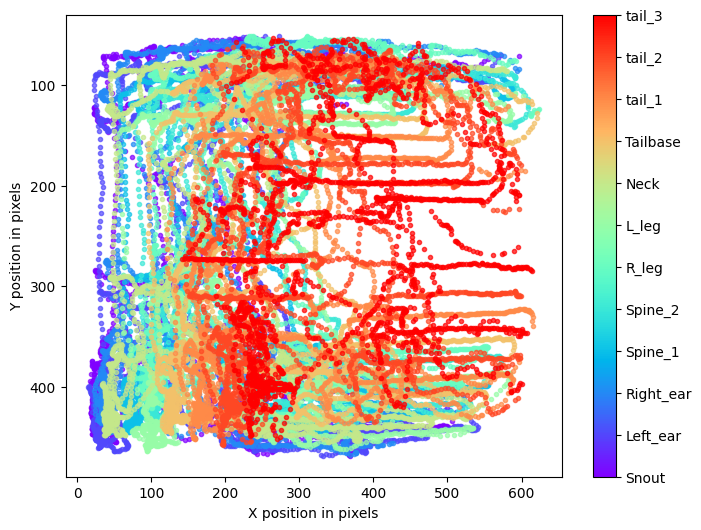

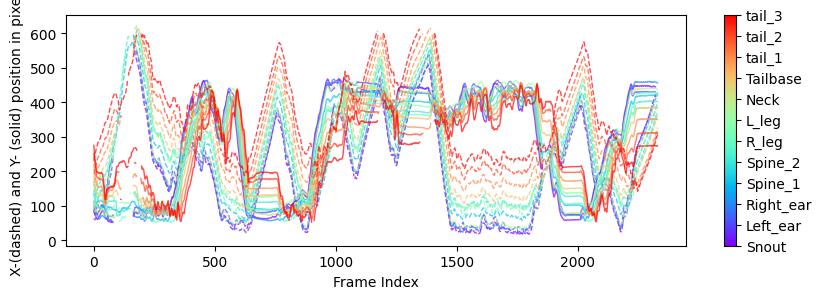

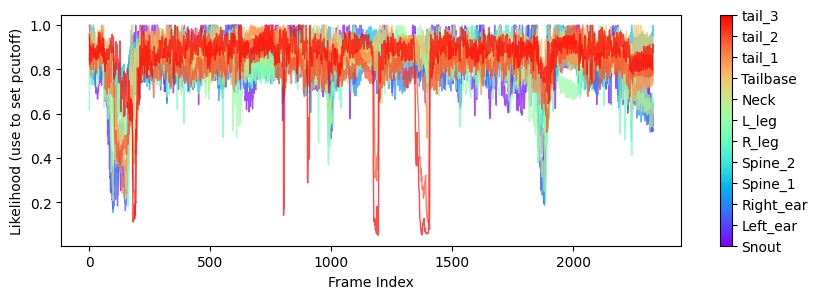

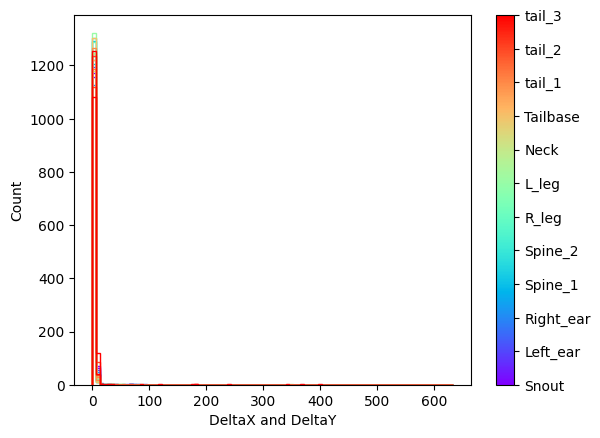

In [ ]:
deeplabcut.plot_trajectories(path_config_file, video, destfolder= destfolder)

# **Creating labeled video**

In [ ]:
deeplabcut.create_labeled_video(path_config_file, videofile_path, pcutoff=0.4)

Analyzing all the videos in the directory...
Starting to process video: /content/drive/My Drive/OpenField-Sahand-2026-05-09/videos/m3v1mp4.mp4
Loading /content/drive/My Drive/OpenField-Sahand-2026-05-09/videos/m3v1mp4.mp4 and data.
Duration of video [s]: 77.67, recorded with 30.0 fps!
Overall # of frames: 2330 with cropped frame dimensions: 640 480
Generating frames and creating video.


100%|██████████| 2330/2330 [00:18<00:00, 124.49it/s]


[True]